In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =pd.read_csv('/content/covid-19 .csv')

In [5]:
df1=df.copy()

In [6]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


T-Test: Kind of an mean difference (if the relation between any groups is / difference is significant or just coincidance)

Scipy is a scintific computing library based on Numpy: can be use is statistical analysis , sampling test, t test , z test

In [8]:
from scipy.stats import ttest_ind

In [9]:
df.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

In [11]:
# Comparing BD and India
bd=df[df['Country/Region']=='Bangladesh']
In=df[df['Country/Region']=='India']

In [14]:
t_test,p_value=ttest_ind(bd['Confirmed'],In['Confirmed'])
print('t_test:',t_test)
print('p_value:',p_value)

if p_value<0.05:
  print('The significant difference is confirmed. Reject Null Hypothesis')
else:
  print('No significant difference is confirmed. Accept Null Hypothesis')

t_test: nan
p_value: nan
No significant difference is confirmed. Accept Null Hypothesis


/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:6316: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df


For sample size less then 30, t test can be done and for more then 30 it should be z test

In [27]:
from statsmodels.stats.weightstats import ztest
z_stat,p_value=ztest(df['Confirmed'],value=1000)
print('z_test:',z_stat)
print('p_value:',p_value)

z_test: 3.1083736321000397
p_value: 0.0018812007589075934


In [17]:
!pip install statsmodels

In [18]:
from statsmodels.stats.weightstats import ztest
z_stat,p_value=ztest(df['Confirmed'],value=1000)
print('z_test:',z_stat)
print('p_value:',p_value)

z_test: 3.1083736321000397
p_value: 0.0018812007589075934


In [25]:
from scipy.stats import f_oneway

df['Death_Rate']=df['Deaths']/df['Confirmed']*100

asia=df[df['Country/Region'].isin(['India', 'Bangladesh', 'Pakistan'])]['Death_Rate']
eu=df[df['Country/Region'].isin(['Italy', 'Spain', 'Germany'])]['Death_Rate']
amrica=df[df['Country/Region'].isin(['US', 'Brazil', 'Mexico'])]['Death_Rate']

In [26]:
f_state,p_value=f_oneway(asia,eu,amrica)
print('F-Statestics:',f_state)
print('p_value:',p_value)

F-Statestics: 3.0983234490341025
p_value: 0.11905082205590552


In [31]:
df['WHO Region'].head(10)

,WHO Region
0,Eastern Mediterranean
1,Europe
2,Africa
3,Europe
4,Africa
5,Americas
6,Americas
7,Europe
8,Western Pacific
9,Europe


In [33]:
asi=df[df['WHO Region']=='South-East Asia']['Death_Rate']
eur=df[df['WHO Region']=='Europe']['Death_Rate']
amri=df[df['WHO Region']=='Americas']['Death_Rate']
f_state,p_value=f_oneway(asi,eur,amri)
print('F-Statestics:',f_state)
print('p_value:',p_value)

F-Statestics: 3.832528376531237
p_value: 0.024971208901438106


Regression analysis : Prediction of the relationship

In [35]:
import statsmodels.api as sm

# Confirmed vs Death relation

x=df[['Confirmed']]
y=df['Deaths']

x=sm.add_constant(x)

model=sm.OLS(y,x).fit() #(creating an object and calling everything)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Deaths   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     1279.
Date:                Thu, 09 Oct 2025   Prob (F-statistic):           4.89e-85
Time:                        15:27:57   Log-Likelihood:                -1858.0
No. Observations:                 187   AIC:                             3720.
Df Residuals:                     185   BIC:                             3726.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        467.4037    377.122      1.239      0.2

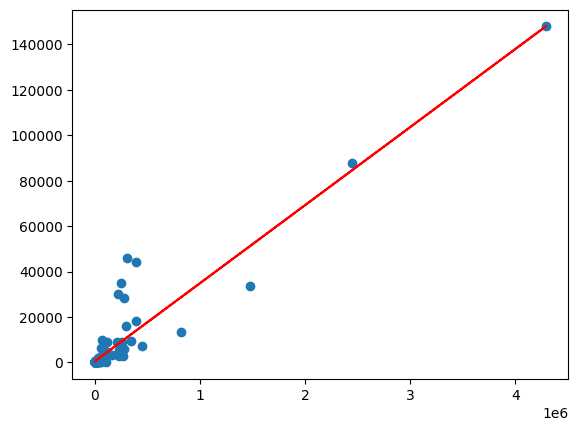

In [36]:
plt.scatter(df['Confirmed'],df['Deaths'])
plt.plot(df['Confirmed'],model.predict(),color='red')
plt.show()

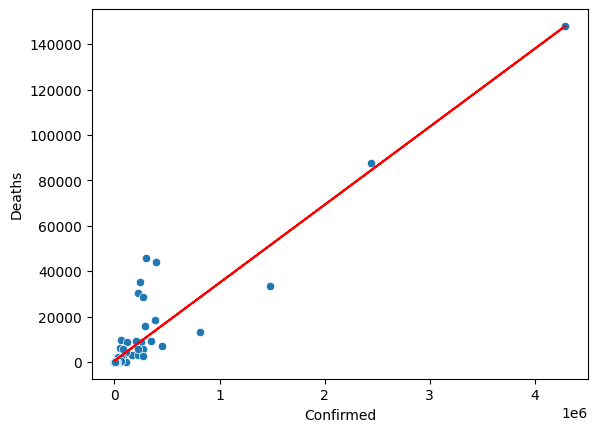

In [37]:
sns.scatterplot(x='Confirmed', y='Deaths', data=df)
plt.plot(df['Confirmed'],model.predict(),color='red')
plt.show()

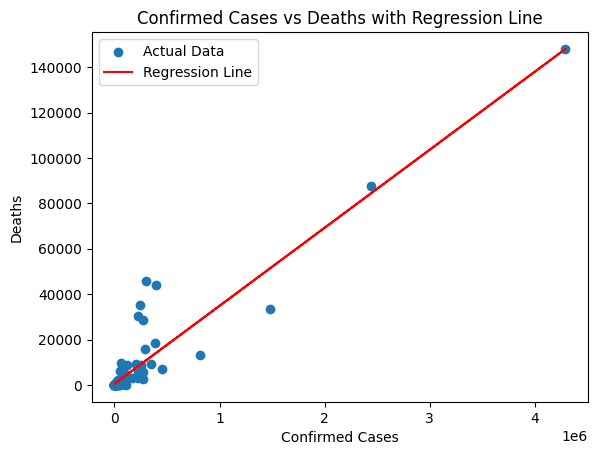

In [39]:
# Create a scatter plot of Confirmed cases vs Deaths
plt.scatter(df['Confirmed'],df['Deaths'], label='Actual Data')


plt.plot(df['Confirmed'],model.predict(),color='red', label='Regression Line')


plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')
plt.title('Confirmed Cases vs Deaths with Regression Line')
plt.legend()

plt.show()

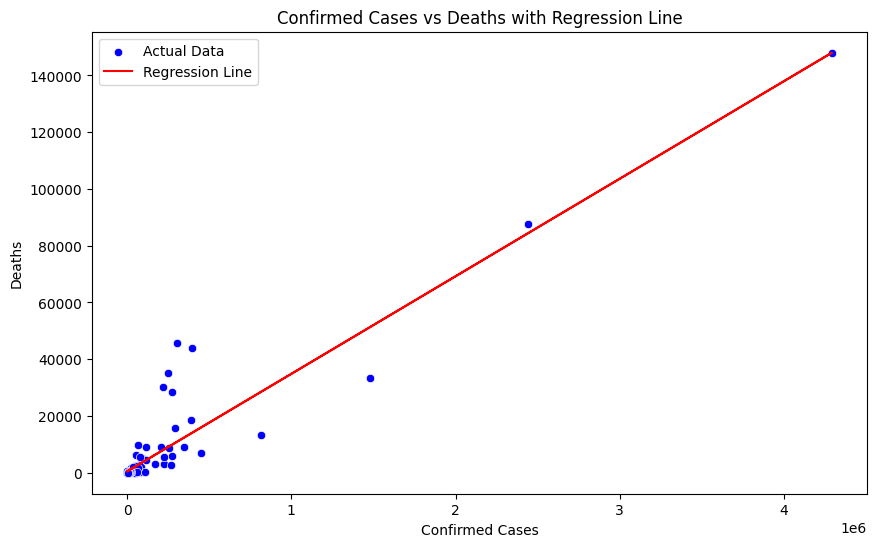

In [43]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Confirmed', y='Deaths', data=df, color='blue', label='Actual Data')

#Regresion line

const=model.params['const']
coef=model.params['Confirmed']
plt.plot(df['Confirmed'],const+coef*x['Confirmed'], color='red',label='Regression Line')

plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')
plt.title('Confirmed Cases vs Deaths with Regression Line')
plt.legend()

plt.show()